<a href="https://www.kaggle.com/code/lalit7881/tmdb-top-10k-rated-movies-eda?scriptVersionId=314478323" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rosemeenshaikh/top-10000-tmdbs-highest-rated-movies/top_rated_movies.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/rosemeenshaikh/top-10000-tmdbs-highest-rated-movies/top_rated_movies.csv")

In [3]:
df.head()

,adult,id,original_language,original_title,overview,popularity,release_date,title,vote_average,vote_count
0,False,278,en,The Shawshank Redemption,Imprisoned in the 1940s for the double murder ...,46.3708,1994-09-23,The Shawshank Redemption,8.718,30171
1,False,238,en,The Godfather,"Spanning the years 1945 to 1955, a chronicle o...",42.0006,1972-03-14,The Godfather,8.686,22787
2,False,240,en,The Godfather Part II,In the continuing saga of the Corleone crime f...,26.8671,1974-12-20,The Godfather Part II,8.571,13812
3,False,424,en,Schindler's List,The true story of how businessman Oskar Schind...,24.2944,1993-12-15,Schindler's List,8.567,17341
4,False,389,en,12 Angry Men,The defense and the prosecution have rested an...,19.4971,1957-04-10,12 Angry Men,8.559,9908


In [4]:
df.tail()

,adult,id,original_language,original_title,overview,popularity,release_date,title,vote_average,vote_count
9995,False,613911,en,Bliss,"A mind-bending love story following Greg who, ...",4.0117,2021-02-05,Bliss,5.507,667
9996,False,10587,en,Police Academy 4: Citizens on Patrol,A new batch of recruits arrives at Police Acad...,2.4525,1987-04-02,Police Academy 4: Citizens on Patrol,5.507,1267
9997,False,11817,en,Bulletproof Monk,A mysterious and immortal Tibetan kung fu mast...,4.0397,2003-03-28,Bulletproof Monk,5.506,990
9998,False,10546,en,The Crow: City of Angels,A murder victim is brought back to life by a m...,3.1747,1996-08-29,The Crow: City of Angels,5.506,598
9999,False,244566,en,Life After Beth,Zach is devastated by the unexpected death of ...,1.7699,2014-08-15,Life After Beth,5.505,721


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   adult              10000 non-null  bool   
 1   id                 10000 non-null  int64  
 2   original_language  10000 non-null  object 
 3   original_title     10000 non-null  object 
 4   overview           9998 non-null   object 
 5   popularity         10000 non-null  float64
 6   release_date       9997 non-null   object 
 7   title              10000 non-null  object 
 8   vote_average       10000 non-null  float64
 9   vote_count         10000 non-null  int64  
dtypes: bool(1), float64(2), int64(2), object(5)
memory usage: 713.0+ KB


In [6]:
df.describe()

,id,popularity,vote_average,vote_count
count,1.000000e+04,10000.000000,10000.000000,10000.000000
mean,2.289950e+05,5.245034,6.742962,2102.696900
std,3.047769e+05,9.623606,0.647942,3359.868343
min,2.000000e+00,0.006900,5.500000,300.000000
25%,1.037575e+04,2.603775,6.237000,475.000000
50%,4.166650e+04,3.765550,6.709500,869.000000
75%,4.084562e+05,5.873200,7.215250,2113.250000
max,1.472638e+06,589.097100,8.718000,39461.000000


In [7]:
df.isnull().sum()

adult                0
id                   0
original_language    0
original_title       0
overview             2
popularity           0
release_date         3
title                0
vote_average         0
vote_count           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(30)

In [9]:
df.columns

Index(['adult', 'id', 'original_language', 'original_title', 'overview',
       'popularity', 'release_date', 'title', 'vote_average', 'vote_count'],
      dtype='object')

In [10]:
df.dtypes

adult                   bool
id                     int64
original_language     object
original_title        object
overview              object
popularity           float64
release_date          object
title                 object
vote_average         float64
vote_count             int64
dtype: object

In [11]:
df.shape

(10000, 10)

In [12]:
df.nunique()

adult                   1
id                   9969
original_language      45
original_title       9692
overview             9959
popularity           9409
release_date         6276
title                9609
vote_average         2539
vote_count           3690
dtype: int64

## EDA

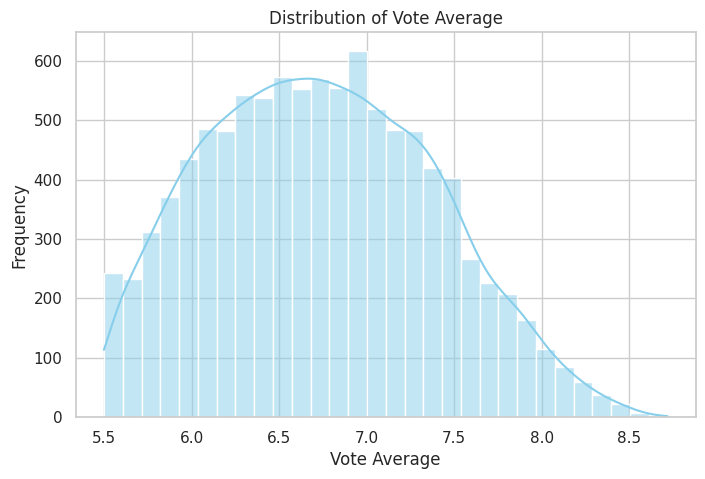

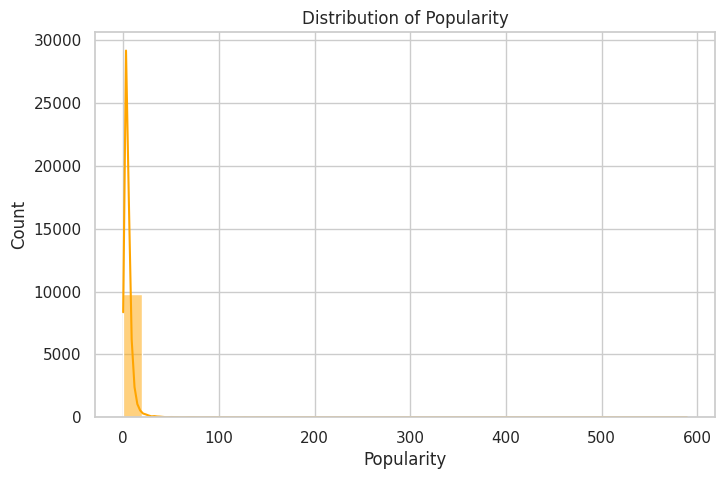

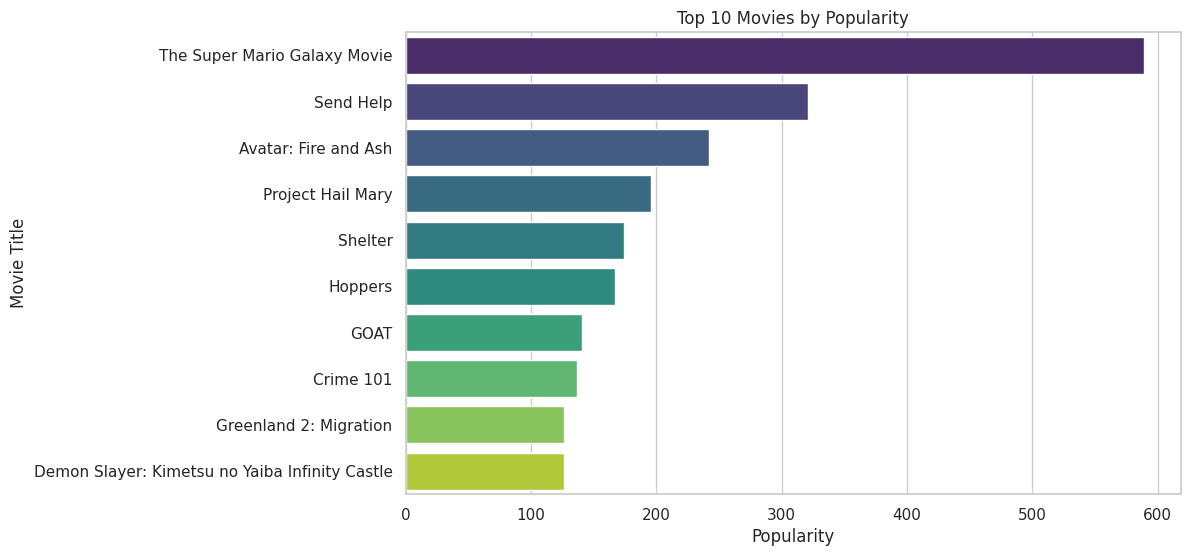

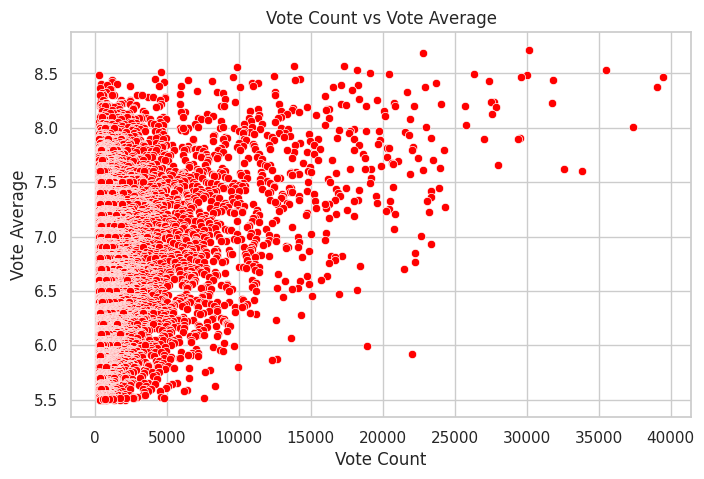

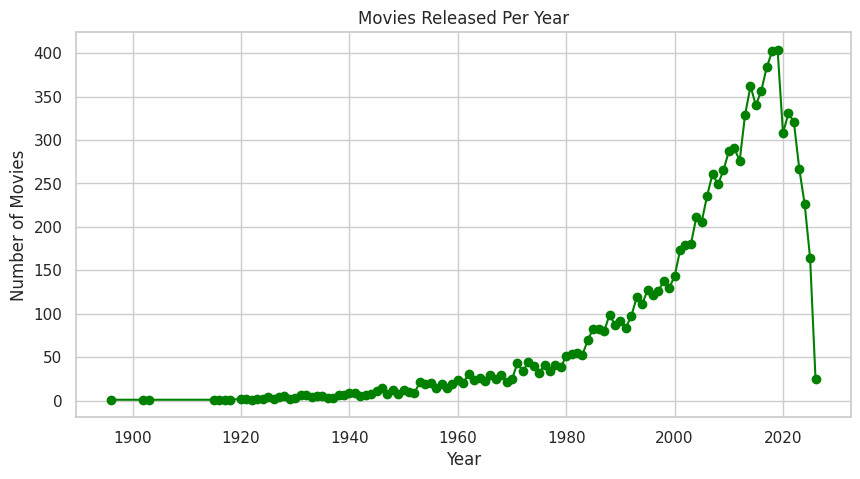

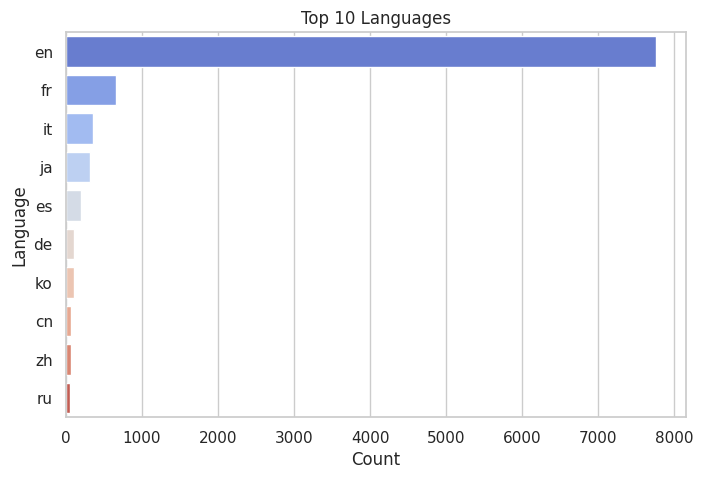

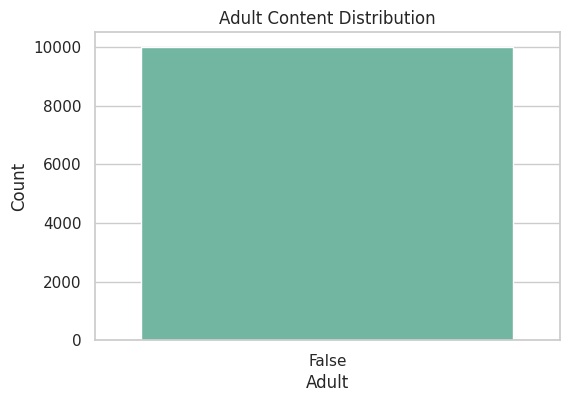

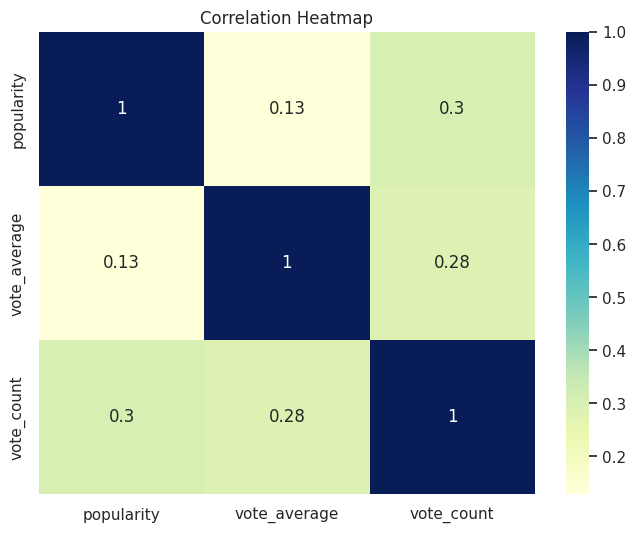

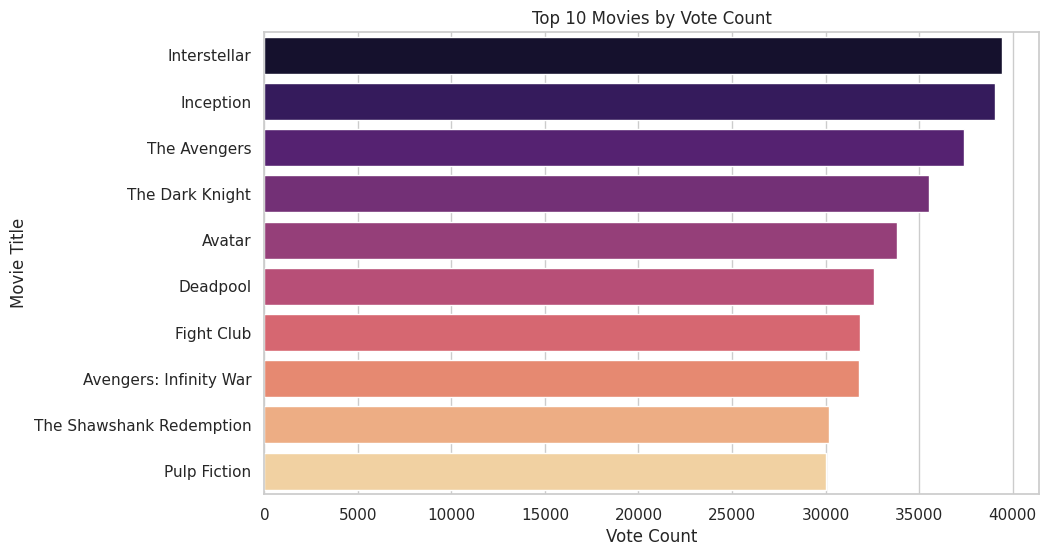

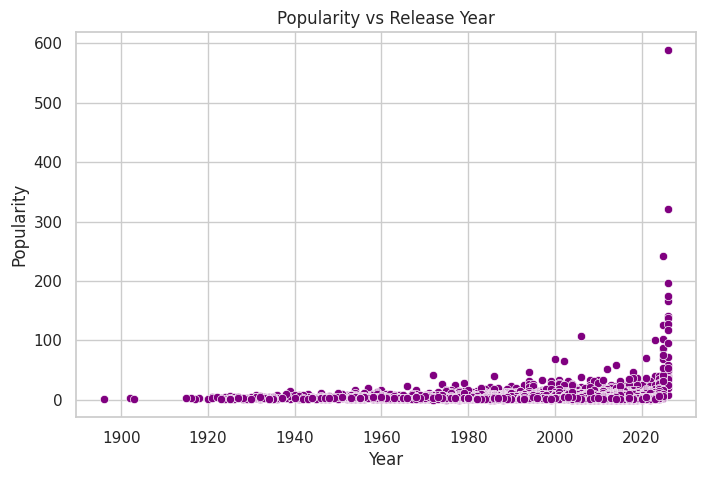

In [13]:
# Convert release_date to datetime
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

# Extract year
df['release_year'] = df['release_date'].dt.year

# Drop missing important values
df = df.dropna(subset=['vote_average', 'popularity'])

# =========================
# SET STYLE
# =========================
sns.set(style="whitegrid")

# =========================
# 1. DISTRIBUTION OF VOTE AVERAGE
# =========================
plt.figure(figsize=(8,5))
sns.histplot(df['vote_average'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Vote Average")
plt.xlabel("Vote Average")
plt.ylabel("Frequency")
plt.show()

# =========================
# 2. POPULARITY DISTRIBUTION
# =========================
plt.figure(figsize=(8,5))
sns.histplot(df['popularity'], bins=30, kde=True, color='orange')
plt.title("Distribution of Popularity")
plt.xlabel("Popularity")
plt.ylabel("Count")
plt.show()

# =========================
# 3. TOP 10 MOVIES BY POPULARITY
# =========================
top_movies = df.sort_values(by='popularity', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='popularity', y='title', data=top_movies, palette='viridis')
plt.title("Top 10 Movies by Popularity")
plt.xlabel("Popularity")
plt.ylabel("Movie Title")
plt.show()

# =========================
# 4. VOTE COUNT VS VOTE AVERAGE
# =========================
plt.figure(figsize=(8,5))
sns.scatterplot(x='vote_count', y='vote_average', data=df, color='red')
plt.title("Vote Count vs Vote Average")
plt.xlabel("Vote Count")
plt.ylabel("Vote Average")
plt.show()

# =========================
# 5. MOVIES RELEASED PER YEAR
# =========================
plt.figure(figsize=(10,5))
df['release_year'].value_counts().sort_index().plot(
    kind='line', color='green', marker='o'
)
plt.title("Movies Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.show()

# =========================
# 6. LANGUAGE DISTRIBUTION (TOP 10)
# =========================
top_lang = df['original_language'].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_lang.values, y=top_lang.index, palette='coolwarm')
plt.title("Top 10 Languages")
plt.xlabel("Count")
plt.ylabel("Language")
plt.show()

# =========================
# 7. ADULT CONTENT COUNT
# =========================
plt.figure(figsize=(6,4))
sns.countplot(x='adult', data=df, palette='Set2')
plt.title("Adult Content Distribution")
plt.xlabel("Adult")
plt.ylabel("Count")
plt.show()

# =========================
# 8. CORRELATION HEATMAP
# =========================
plt.figure(figsize=(8,6))
corr = df[['popularity', 'vote_average', 'vote_count']].corr()

sns.heatmap(corr, annot=True, cmap='YlGnBu')
plt.title("Correlation Heatmap")
plt.show()

# =========================
# 9. TOP 10 MOVIES BY VOTE COUNT
# =========================
top_votes = df.sort_values(by='vote_count', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='vote_count', y='title', data=top_votes, palette='magma')
plt.title("Top 10 Movies by Vote Count")
plt.xlabel("Vote Count")
plt.ylabel("Movie Title")
plt.show()

# =========================
# 10. POPULARITY VS YEAR (SCATTER)
# =========================
plt.figure(figsize=(8,5))
sns.scatterplot(x='release_year', y='popularity', data=df, color='purple')
plt.title("Popularity vs Release Year")
plt.xlabel("Year")
plt.ylabel("Popularity")
plt.show()

## Feature engineering


Logistic Regression Accuracy: 0.7445

Logistic Regression Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.90      0.82      1281
           1       0.72      0.47      0.57       719

    accuracy                           0.74      2000
   macro avg       0.74      0.68      0.69      2000
weighted avg       0.74      0.74      0.73      2000


Random Forest Accuracy: 0.7325

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.85      0.80      1281
           1       0.66      0.52      0.58       719

    accuracy                           0.73      2000
   macro avg       0.71      0.69      0.69      2000
weighted avg       0.73      0.73      0.72      2000



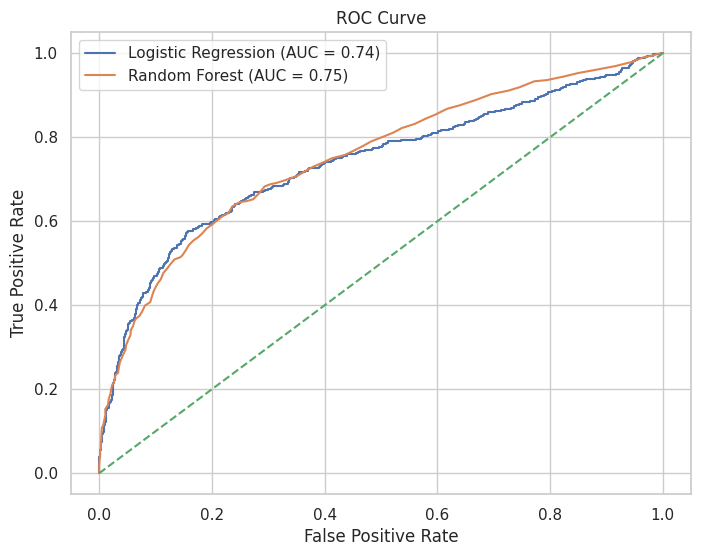

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, roc_curve, auc, classification_report

# =========================
# FEATURE ENGINEERING
# =========================
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year

# =========================
# TARGET CREATION
# =========================
df['target'] = (df['vote_average'] >= 7).astype(int)

# =========================
# FEATURES
# =========================
features = [
    'popularity',
    'vote_count',
    'release_year',
    'original_language',
    'adult'
]

X = df[features]
y = df['target']

# =========================
# TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# PREPROCESSING (FIXED)
# =========================
numeric_features = ['popularity', 'vote_count', 'release_year']
categorical_features = ['original_language', 'adult']

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # 🔥 FIX
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # 🔥 FIX
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# =========================
# MODELS
# =========================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# =========================
# TRAIN + EVALUATE
# =========================
plt.figure(figsize=(8,6))

for name, model in models.items():
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name} Accuracy: {acc:.4f}")
    
    # Report
    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_test, y_pred))
    
    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# =========================
# ROC CURVE
# =========================
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Thank you...pls upvote!!!!!!!!!!!!
